# Week 5 — Supervised Learning: Regression
**AI/ML Internship Program — Month 2: Core ML**

This notebook covers:
1. Linear Regression from first principles (cost function, gradient descent intuition)
2. **Main Project:** House Price Prediction with scikit-learn — train/test split, model training, evaluation (MAE, MSE, RMSE, R²)
3. Logistic Regression on a binary classification dataset

## 1. Linear Regression — The Idea

Linear Regression fits a straight line (or hyperplane, with multiple features) through the data:

`price = w1*feature1 + w2*feature2 + ... + b`

- The **cost function** (Mean Squared Error) measures how wrong the line's predictions are, on average, squared.
- **Gradient descent** nudges `w1, w2, ..., b` step by step to make the cost function smaller — this is what "training" the model means.
- Once trained, the model's weights `w` tell you how much each feature matters, and in which direction.

Below is a tiny from-scratch example with one feature, so you can see gradient descent actually fitting a line before we let scikit-learn do the heavy lifting on the real dataset.

Learned: price ≈ 21.68 * size + 17.43


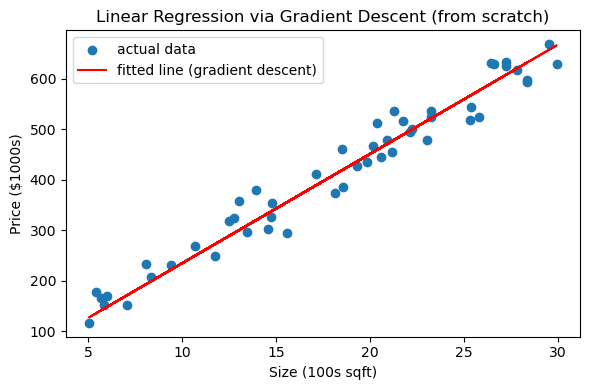

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Fake data: house size (in 100s of sqft) vs price (in $1000s), roughly linear with noise
size = rng.uniform(5, 30, 50)
price = 20 * size + 50 + rng.normal(0, 30, 50)

# Start with random guesses for slope (w) and intercept (b)
w, b = 0.0, 0.0
learning_rate = 0.001
n = len(size)

for epoch in range(2000):
    y_pred = w * size + b
    error = y_pred - price
    dw = (2/n) * np.dot(error, size)
    db = (2/n) * np.sum(error)
    w -= learning_rate * dw
    b -= learning_rate * db

print(f"Learned: price ≈ {w:.2f} * size + {b:.2f}")

plt.figure(figsize=(6, 4))
plt.scatter(size, price, label="actual data")
plt.plot(size, w * size + b, color="red", label="fitted line (gradient descent)")
plt.xlabel("Size (100s sqft)")
plt.ylabel("Price ($1000s)")
plt.title("Linear Regression via Gradient Descent (from scratch)")
plt.legend()
plt.tight_layout()
plt.show()